In [8]:
from ultralytics import YOLO
from pathlib import Path
from IPython.display import Image, display
import wandb
import yaml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

local_path="best.pt"

try:
    api = wandb.Api()
    artifact = api.artifact("jotamunz-org/wandb-registry-pigeon-guard/yolo-model:production")
    artifact_dir = artifact.download()
    pt_path = next(Path(artifact_dir).rglob("*.pt"))
    print("\033[33mLoaded model from wandb\033[0m")
except:
    print(f"\033[33mloading from wandb didnt work, trying local path: {local_path}\033[0m")
    pt_path = local_path

data = "dataset/data.yaml"
imgsz = 224
split = "test"

loading from wandb didnt work, trying local path: best.pt


### Default ultralytics plot (ignores True Negatives for some reason..)

Ultralytics 8.4.47 🚀 Python-3.13.12 torch-2.11.0+cu130 CPU (Intel Core Ultra 7 265U)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4044.2±763.8 MB/s, size: 108.4 KB)
val: Scanning /home/bhed/Studium/pidgeon1/model/dataset/labels.cache... 317 images, 111 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 318/318 88.9Mit/s 0.0s
val: /home/bhed/Studium/pidgeon1/model/dataset/images/2026-01-08_12-18-47.jpg: ignoring corrupt image/label: cannot identify image file '/home/bhed/Studium/pidgeon1/model/dataset/images/2026-01-08_12-18-47.jpg'
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 3.8it/s 5.3s0.3s
                   all        317        294      0.979      0.955      0.966      0.609
Speed: 0.1ms preprocess, 10.2ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /home/bhed/Studium/pidgeon/model/runs/detect/val-55


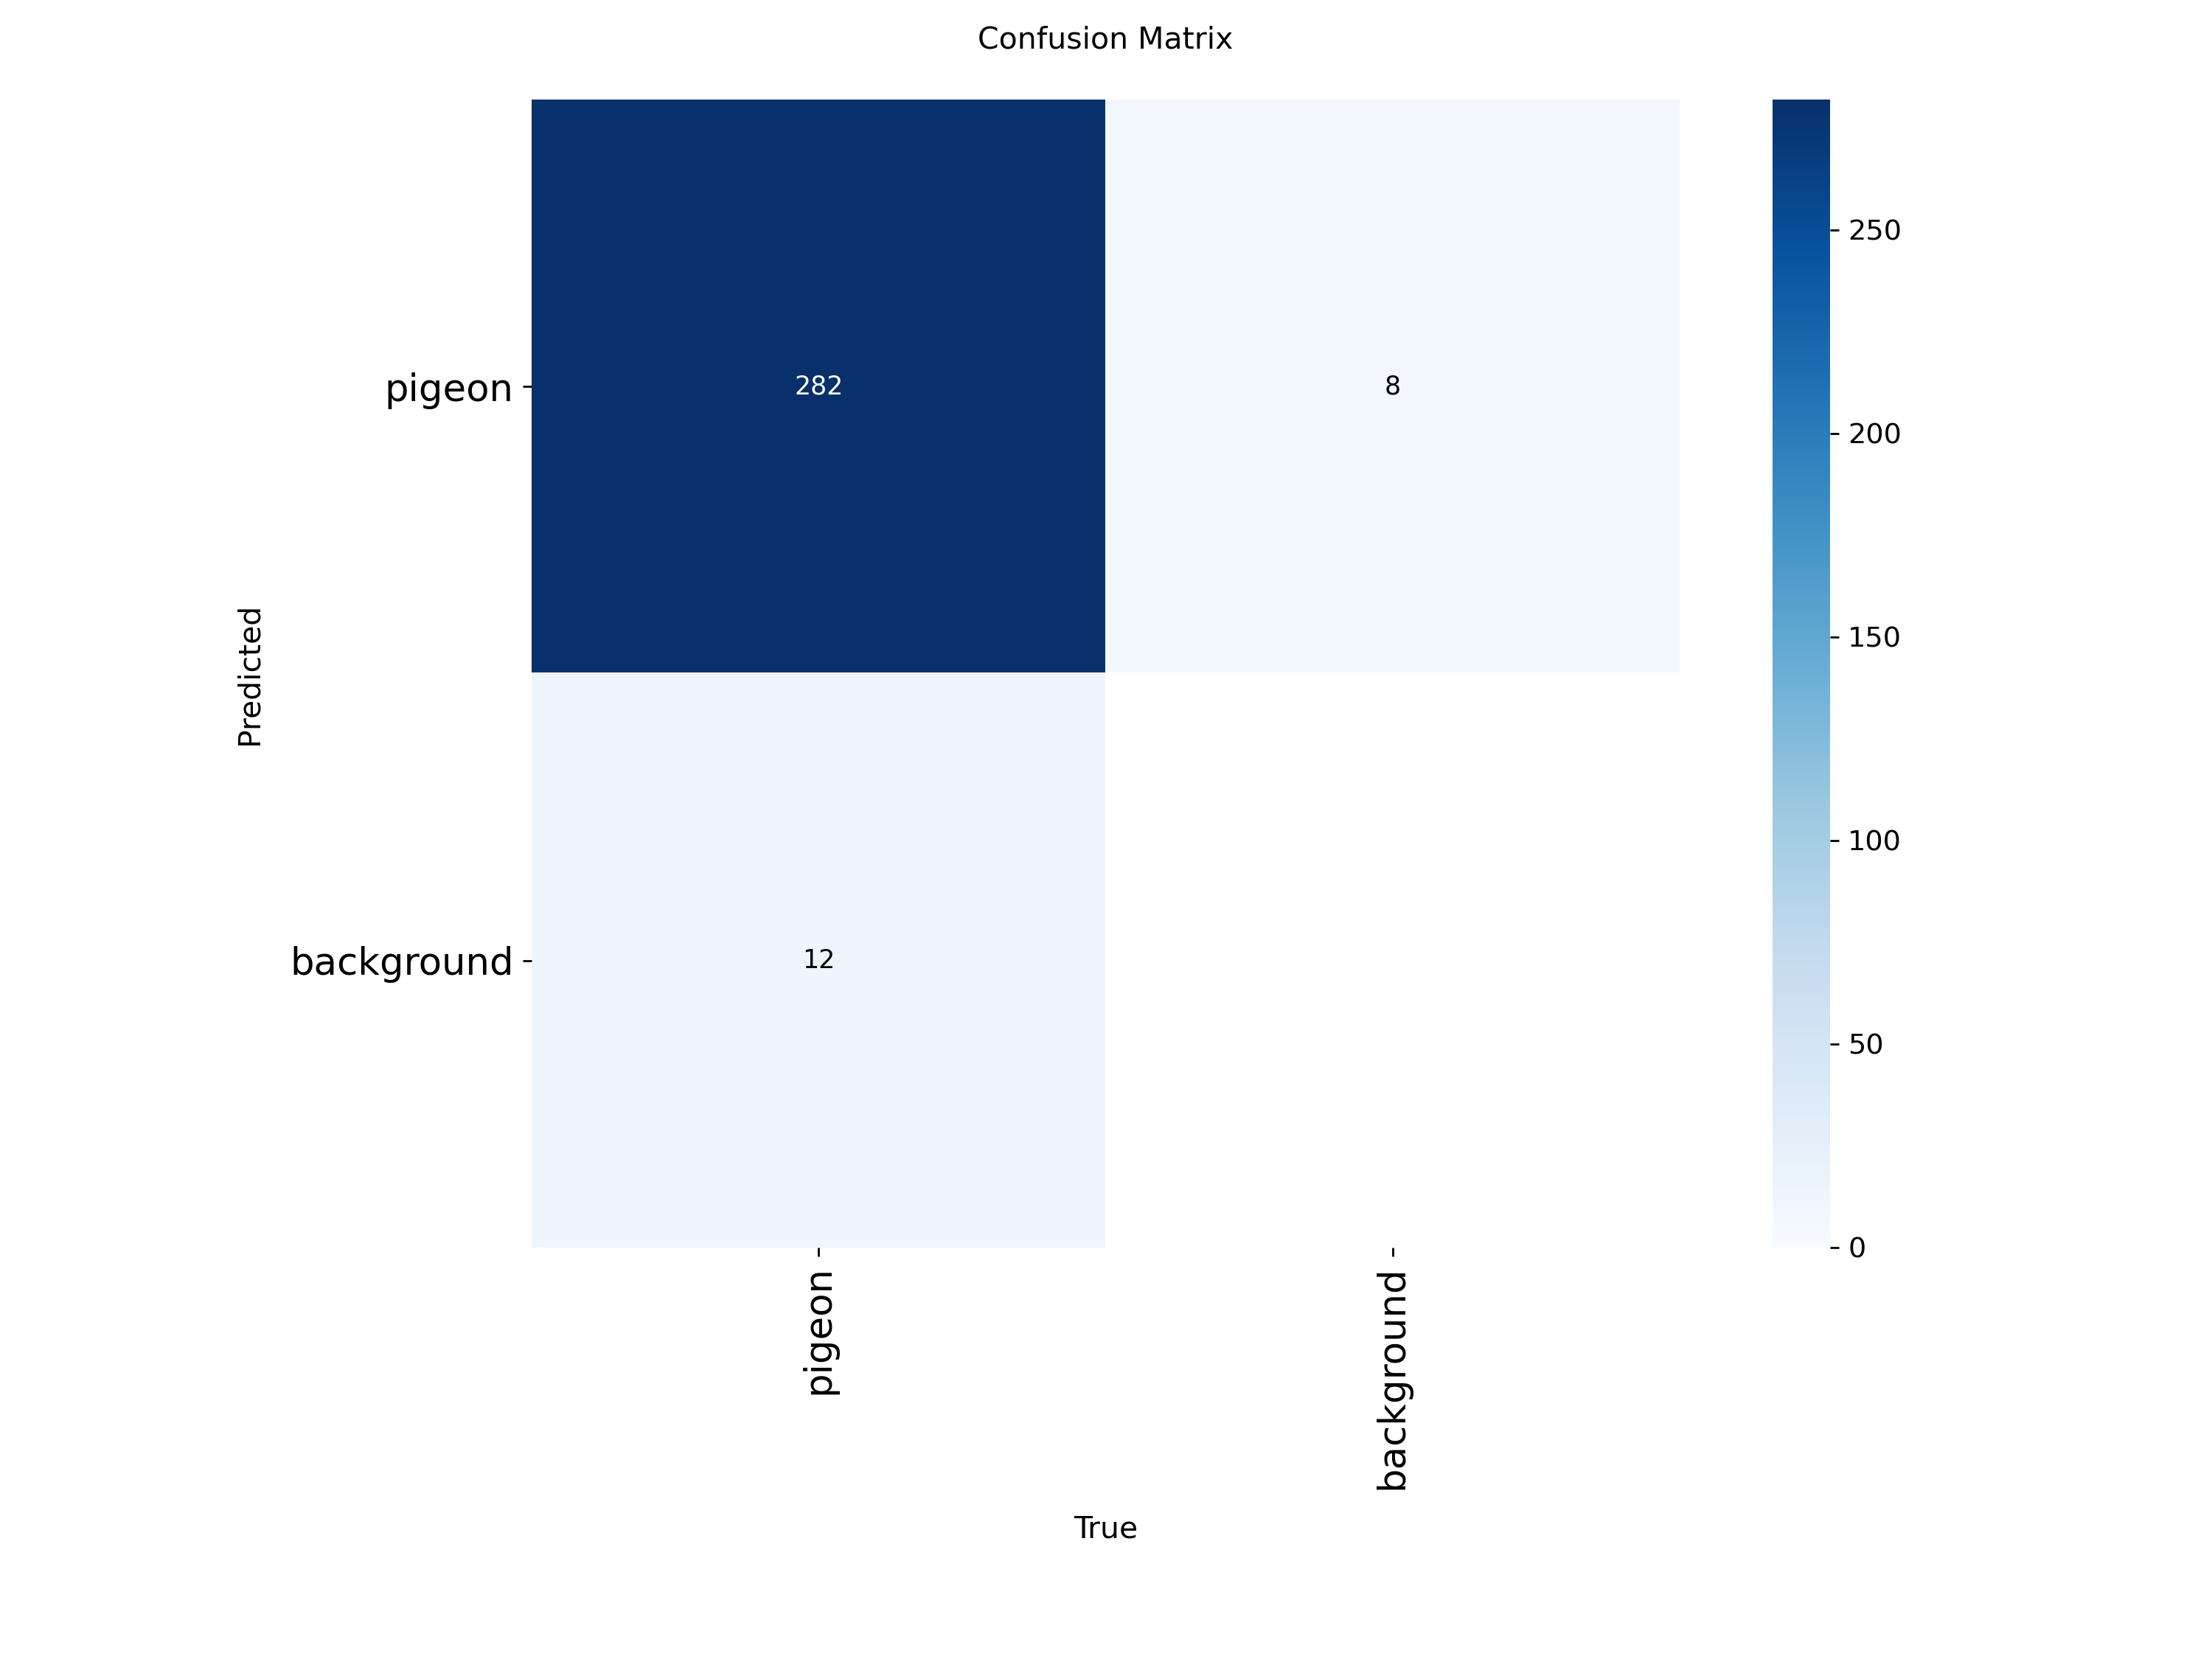

In [9]:
model = YOLO(str(pt_path))
metrics = model.val(data=data, imgsz=imgsz, split=split, plots=True)
cm_path = Path(metrics.save_dir) / "confusion_matrix.png"
display(Image(filename=str(cm_path)))

### Own confusion matrix with True Negatives

In [10]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def label_path(split_file, img_path):
    return (split_file.parent / str(img_path).replace("images", "labels", 1)).with_suffix(".txt")

def partition_split(split_file):
    images = [Path(p.strip()) for p in split_file.read_text().splitlines() if p.strip()]
    bg     = [p for p in images if not label_path(split_file, p).exists()
                                 or label_path(split_file, p).stat().st_size == 0]
    return bg

def count_bg_detections(bg_images, split_file, model, imgsz):
    fired = 0
    for img_path in bg_images:
        try:
            r = model.predict(str(split_file.parent / img_path), imgsz=imgsz, verbose=False)
            if len(r[0].boxes) > 0:
                fired += 1
        except Exception as e:
            print(f"  Skipping {img_path.name}: {e}")
    return fired

# ── Run validation ────────────────────────────────────────────────────────────
with open(data) as f:
    cfg = yaml.safe_load(f)

dataset_root = Path(cfg["path"])
split_file   = dataset_root / cfg[split]

model   = YOLO(pt_path)
metrics = model.val(data=data, imgsz=imgsz, split=split, plots=True)

cm = metrics.confusion_matrix.matrix
tp = int(cm[0, 0])
fp = int(cm[0, 1])
fn = int(cm[1, 0])

bg_imgs = partition_split(split_file)
bg_fp   = count_bg_detections(bg_imgs, split_file, model, imgsz)
tn      = len(bg_imgs) - bg_fp

# ── Normalized matrix ─────────────────────────────────────────────────────────
raw        = np.array([[tp,    bg_fp],
                       [fn,    tn   ]], dtype=float)
col_totals = np.array([tp + fn, len(bg_imgs)], dtype=float)
normalized = raw / col_totals

Ultralytics 8.4.47 🚀 Python-3.13.12 torch-2.11.0+cu130 CPU (Intel Core Ultra 7 265U)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 5386.6±1153.5 MB/s, size: 108.6 KB)
val: Scanning /home/bhed/Studium/pidgeon1/model/dataset/labels.cache... 317 images, 111 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 318/318 102.6Mit/s 0.0s
val: /home/bhed/Studium/pidgeon1/model/dataset/images/2026-01-08_12-18-47.jpg: ignoring corrupt image/label: cannot identify image file '/home/bhed/Studium/pidgeon1/model/dataset/images/2026-01-08_12-18-47.jpg'
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 3.5it/s 5.7s0.3s
                   all        317        294      0.979      0.955      0.966      0.609
Speed: 0.2ms preprocess, 11.0ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /home/bhed/Studium/pidgeon/model/runs/detect/val-56
  Skipping 2

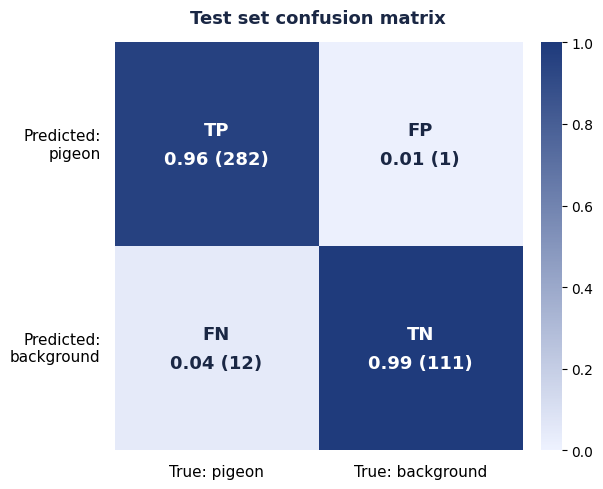

In [11]:
%matplotlib inline
# ── Plot ──────────────────────────────────────────────────────────────────────
cmap = LinearSegmentedColormap.from_list("cm", ["#eef2ff", "#1e3a7b"])
tags = [["TP", "FP"], ["FN", "TN"]]

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

im = ax.imshow(normalized, cmap=cmap, vmin=0, vmax=1, aspect="equal")

ax.set_xticks([0, 1]); ax.set_xticklabels(["True: pigeon", "True: background"], fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(["Predicted:\npigeon", "Predicted:\nbackground"], fontsize=11, va="center")
ax.tick_params(length=0, pad=10)
for spine in ax.spines.values():
    spine.set_visible(False)

for i in range(2):
    for j in range(2):
        v     = normalized[i, j]
        count = int(raw[i, j])
        fg    = "white" if v > 0.5 else "#1a2744"
        ax.text(j, i, f"{tags[i][j]}\n{v:.2f} ({count})",
                ha="center", va="center", fontsize=13, color=fg, fontweight="bold",
                linespacing=1.8)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).outline.set_visible(False)
ax.set_title("Test set confusion matrix", fontsize=13,
             fontweight="bold", color="#1a2744", pad=14)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()